<a href="https://colab.research.google.com/github/NaoKB/EML/blob/main/k_brazos/Softmax.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Estudio intrafamilia: Softmax/Boltzmann

Este notebook analiza la sensibilidad de Softmax a la temperatura `τ`. La política asigna mayor probabilidad a los brazos con mejor estimación Q, pero conserva probabilidad positiva para brazos subóptimos.

Configuraciones evaluadas:

- `τ = 0.10`: explotación muy fuerte.
- `τ = 0.35`: compromiso intermedio.
- `τ = 1.00`: exploración más distribuida.

El punto crítico de Softmax es la escala: la misma temperatura no tiene el mismo efecto cuando las recompensas son binarias, de conteo o continuas con varianza alta.

## Preparación del entorno

In [1]:
from pathlib import Path
import sys
import subprocess

REPO_URL = "https://github.com/NaoKB/EML.git"  # Actualizar si se publica en otro repositorio.


def find_project_root():
    candidates = [Path.cwd(), *Path.cwd().parents, Path("/content/EML/k_brazos"), Path("/content/k_brazos")]
    for candidate in candidates:
        if (candidate / "src" / "bandit_experiment.py").exists():
            return candidate
    return None

PROJECT_ROOT = find_project_root()
if PROJECT_ROOT is None:
    clone_target = Path("/content/EML")
    if not clone_target.exists():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(clone_target)], check=True)
    PROJECT_ROOT = find_project_root()

if PROJECT_ROOT is None:
    raise RuntimeError("No se ha encontrado la carpeta del proyecto con src/bandit_experiment.py")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Raíz del proyecto: {PROJECT_ROOT}")

Raíz del proyecto: /mnt/data/rev_k/k_brazos


In [2]:
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

from src.algorithms import EpsilonGreedy, UCB1, Softmax
from src.bandit_experiment import BanditExperiment, REWARDS_NAME, OPTIMAL_NAME, REGRET_NAME, SUMMARY_NAME, ARM_STATS_NAME
from src.plotting import plot_average_rewards, plot_optimal_selections, plot_regret, plot_arm_statistics, plot_summary_heatmap
from src.scenarios import build_scenarios, scenario_table, describe_bandit

SEED = 2026
STEPS = 500
RUNS = 75
SMOOTH_WINDOW = 31

np.random.seed(SEED)
scenarios = build_scenarios()
display(scenario_table(scenarios).round(4))

,escenario,brazo,distribución,parámetros,E[r],gap,óptimo
0,bernoulli,0,Bernoulli,ArmBernoulli(p=0.041),0.041,0.023,False
1,bernoulli,1,Bernoulli,ArmBernoulli(p=0.048),0.048,0.016,False
2,bernoulli,2,Bernoulli,ArmBernoulli(p=0.052),0.052,0.012,False
3,bernoulli,3,Bernoulli,ArmBernoulli(p=0.055),0.055,0.009,False
4,bernoulli,4,Bernoulli,ArmBernoulli(p=0.058),0.058,0.006,False
5,bernoulli,5,Bernoulli,ArmBernoulli(p=0.06),0.060,0.004,False
6,bernoulli,6,Bernoulli,ArmBernoulli(p=0.064),0.064,0.000,True
7,binomial,0,Binomial,"ArmBinomial(n=80, p=0.085)",6.800,9.360,False
8,binomial,1,Binomial,"ArmBinomial(n=80, p=0.115)",9.200,6.960,False
9,binomial,2,Binomial,"ArmBinomial(n=80, p=0.135)",10.800,5.360,False


## Ejecución del experimento

In [3]:
def algorithm_factory(k):
    return [Softmax(k, temperature=tau) for tau in [0.10, 0.35, 1.00]]

results, algorithms_by_scenario = BanditExperiment.run_many(
    scenarios,
    algorithm_factory,
    steps=STEPS,
    runs=RUNS,
    seed=SEED + 200,
)

## Resultados por escenario

## Bernoulli: anuncios con CTR bajo

Prueba difícil por baja señal y gaps pequeños; favorece políticas que acumulen evidencia sin sobreexplorar.

```text
Bandit with 7 arms: ArmBernoulli(p=0.041), ArmBernoulli(p=0.048), ArmBernoulli(p=0.052), ArmBernoulli(p=0.055), ArmBernoulli(p=0.058), ArmBernoulli(p=0.06), ArmBernoulli(p=0.064)

Resumen de medias reales usadas solo para evaluación:
  brazo 0: E[r]=0.0410, gap=0.0230
  brazo 1: E[r]=0.0480, gap=0.0160
  brazo 2: E[r]=0.0520, gap=0.0120
  brazo 3: E[r]=0.0550, gap=0.0090
  brazo 4: E[r]=0.0580, gap=0.0060
  brazo 5: E[r]=0.0600, gap=0.0040
  brazo 6: E[r]=0.0640, gap=0.0000 <- óptimo
```

,algoritmo,recompensa_media_total,recompensa_media_último_20%,regret_final,% óptimo_final,% óptimo_último_20%,% tiradas_brazo_óptimo
0,Softmax τ=0.1,0.0534,0.0540,4.8113,12.0000,14.0800,15.0160
1,Softmax τ=0.35,0.0542,0.0571,4.9594,9.3333,15.0933,14.3067
2,Softmax τ=1,0.0550,0.0557,4.9927,18.6667,14.0133,13.8987


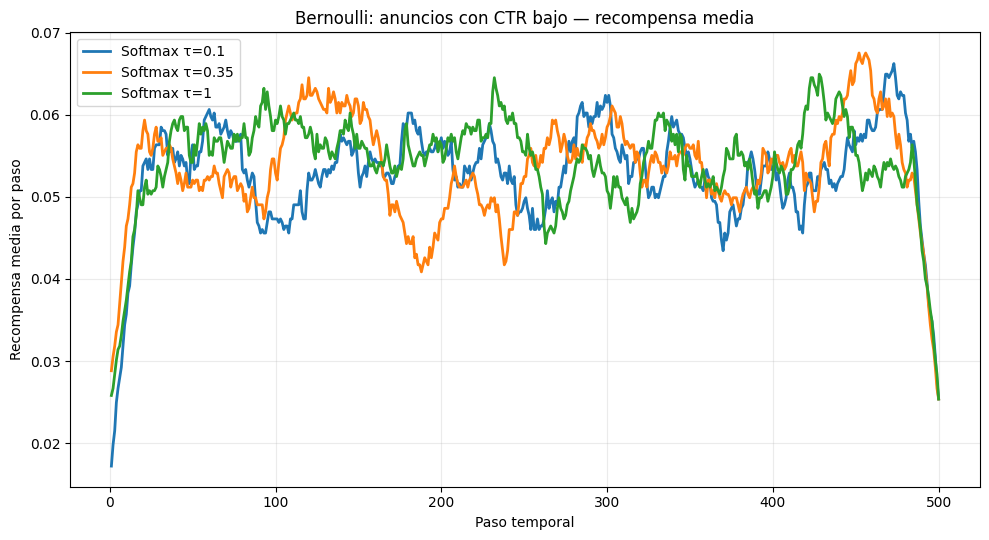

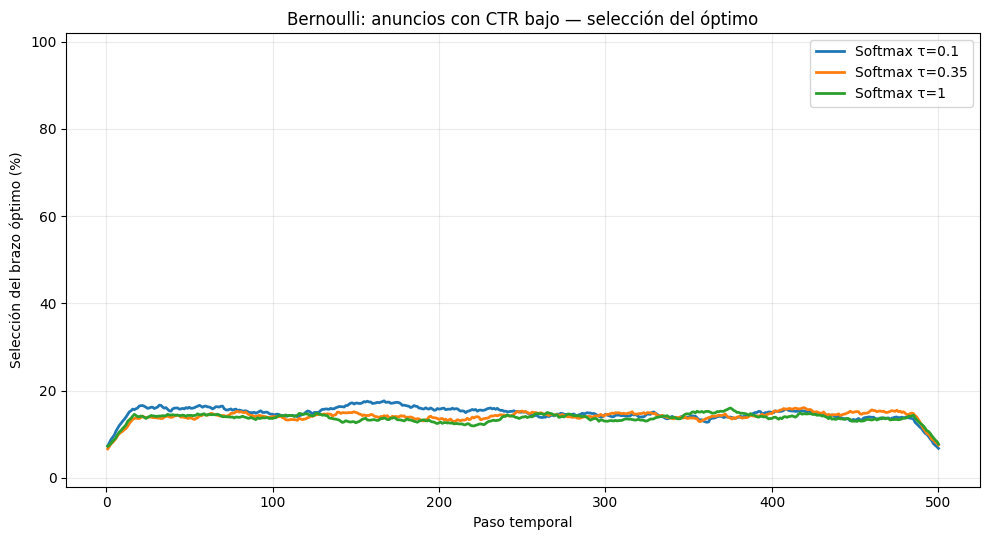

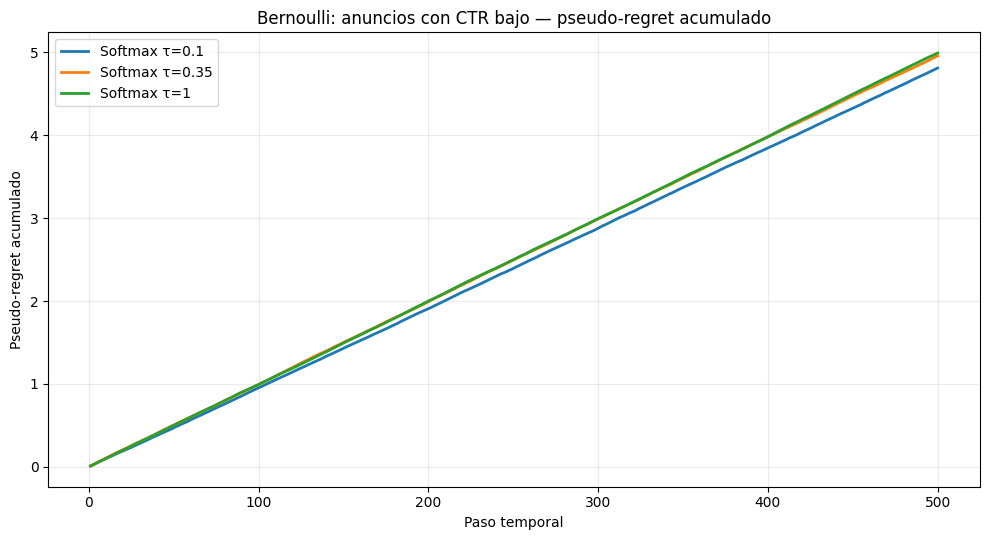

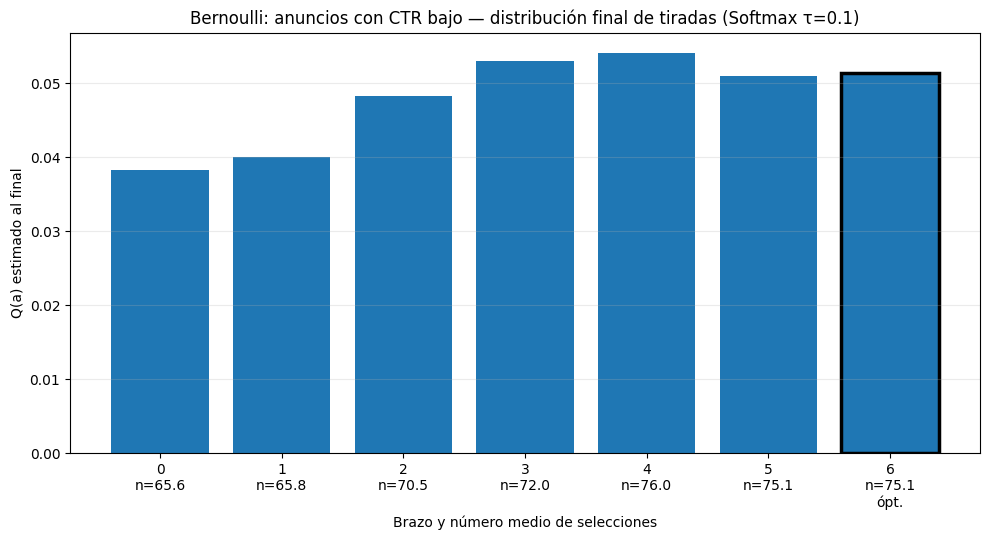

## Binomial: promociones por lotes

La escala de recompensa es mayor y la varianza depende de p; sirve para observar sensibilidad a la escala.

```text
Bandit with 7 arms: ArmBinomial(n=80, p=0.085), ArmBinomial(n=80, p=0.115), ArmBinomial(n=80, p=0.135), ArmBinomial(n=80, p=0.158), ArmBinomial(n=80, p=0.176), ArmBinomial(n=80, p=0.19), ArmBinomial(n=80, p=0.202)

Resumen de medias reales usadas solo para evaluación:
  brazo 0: E[r]=6.8000, gap=9.3600
  brazo 1: E[r]=9.2000, gap=6.9600
  brazo 2: E[r]=10.8000, gap=5.3600
  brazo 3: E[r]=12.6400, gap=3.5200
  brazo 4: E[r]=14.0800, gap=2.0800
  brazo 5: E[r]=15.2000, gap=0.9600
  brazo 6: E[r]=16.1600, gap=0.0000 <- óptimo
```

,algoritmo,recompensa_media_total,recompensa_media_último_20%,regret_final,% óptimo_final,% óptimo_último_20%,% tiradas_brazo_óptimo
0,Softmax τ=1,12.8456,12.9995,1641.8923,21.3333,21.3333,20.3280
1,Softmax τ=0.1,12.3039,12.2523,1915.2000,14.6667,14.6667,14.6667
2,Softmax τ=0.35,12.2020,12.2371,1984.5333,18.6667,18.6667,18.6667


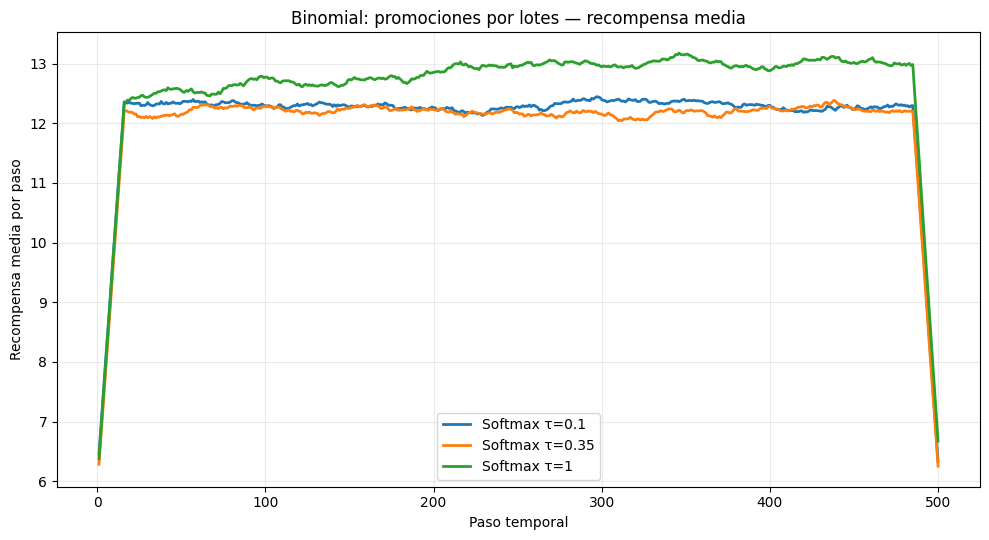

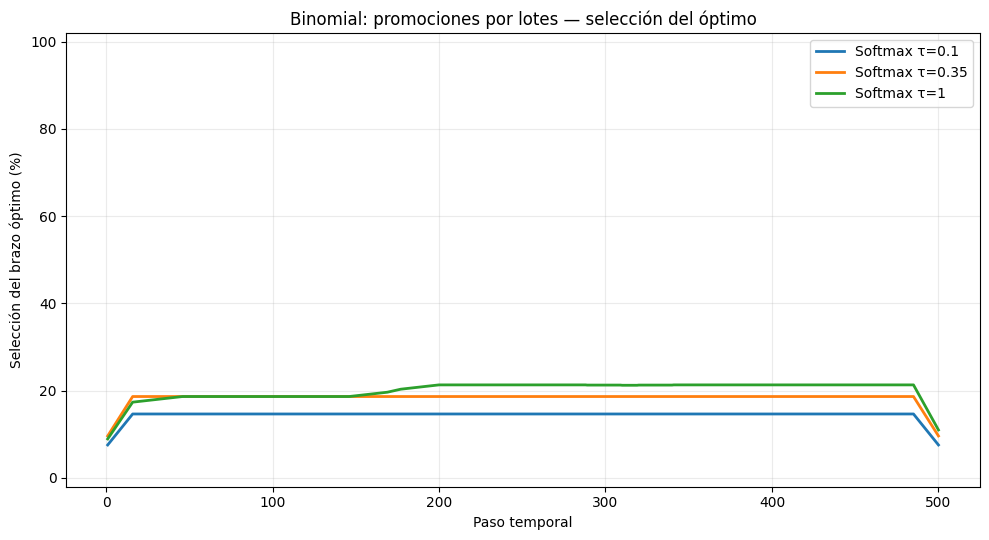

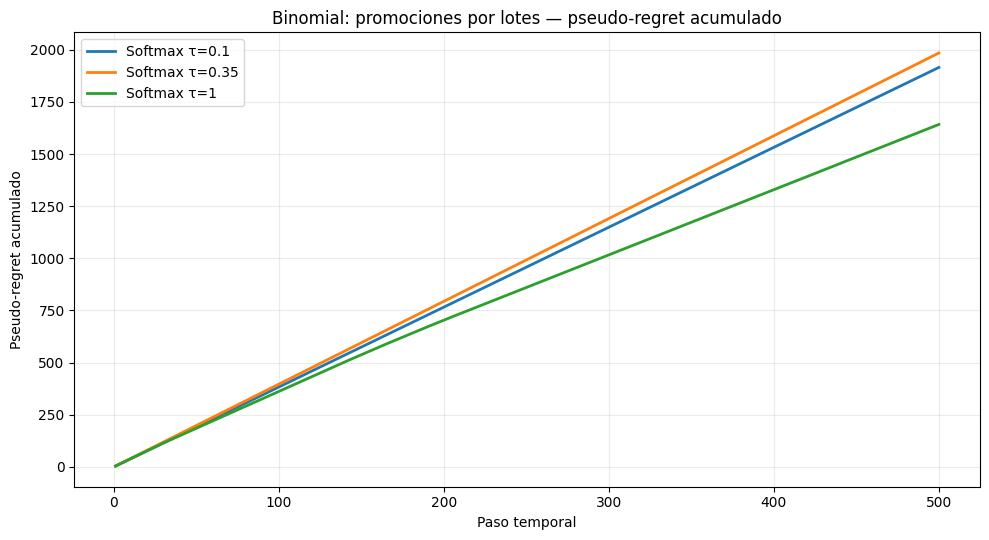

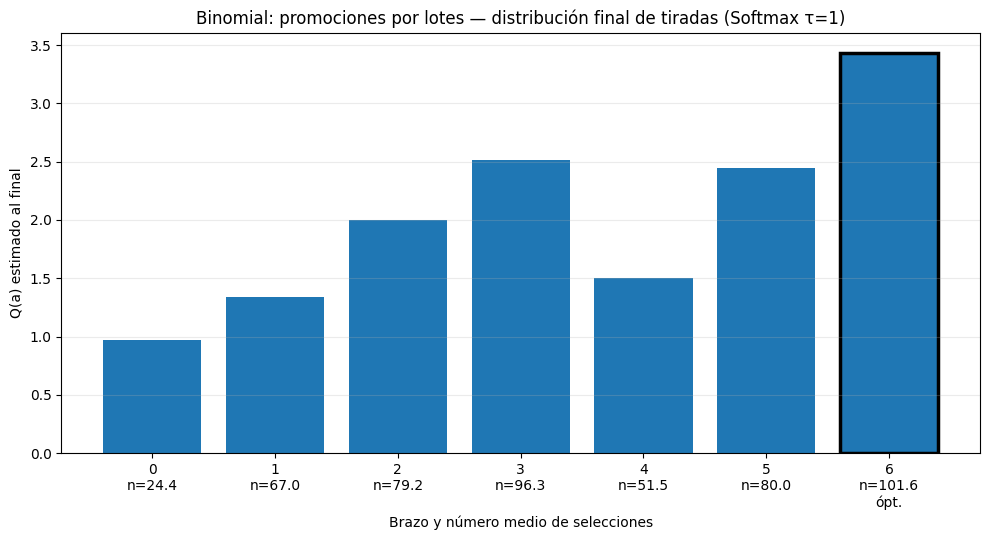

## Normal: recomendadores de watch-time

Permite recompensas continuas y ruido heterocedástico; el brazo más variable no siempre es el mejor.

```text
Bandit with 7 arms: ArmNormal(mu=4.4, sigma=1.7), ArmNormal(mu=5.0, sigma=2.8), ArmNormal(mu=5.4, sigma=1.2), ArmNormal(mu=5.7, sigma=4.0), ArmNormal(mu=6.1, sigma=1.0), ArmNormal(mu=6.25, sigma=3.2), ArmNormal(mu=6.55, sigma=1.5)

Resumen de medias reales usadas solo para evaluación:
  brazo 0: E[r]=4.4000, gap=2.1500
  brazo 1: E[r]=5.0000, gap=1.5500
  brazo 2: E[r]=5.4000, gap=1.1500
  brazo 3: E[r]=5.7000, gap=0.8500
  brazo 4: E[r]=6.1000, gap=0.4500
  brazo 5: E[r]=6.2500, gap=0.3000
  brazo 6: E[r]=6.5500, gap=0.0000 <- óptimo
```

,algoritmo,recompensa_media_total,recompensa_media_último_20%,regret_final,% óptimo_final,% óptimo_último_20%,% tiradas_brazo_óptimo
0,Softmax τ=1,5.9668,5.9885,292.6233,34.6667,27.8800,26.2187
1,Softmax τ=0.35,5.6781,5.7030,429.7140,14.6667,14.6667,14.6640
2,Softmax τ=0.1,5.6611,5.6689,444.3440,16.0000,16.0000,16.0000


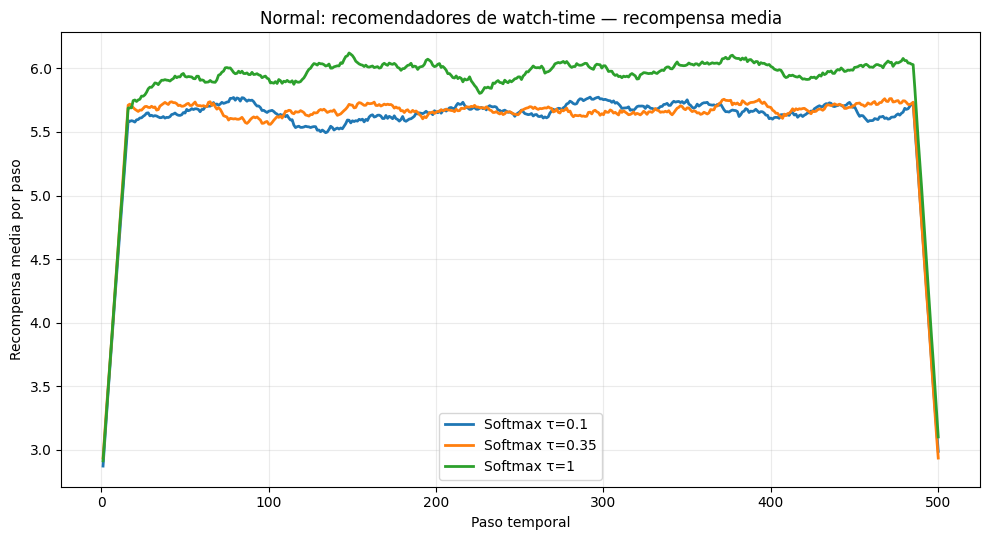

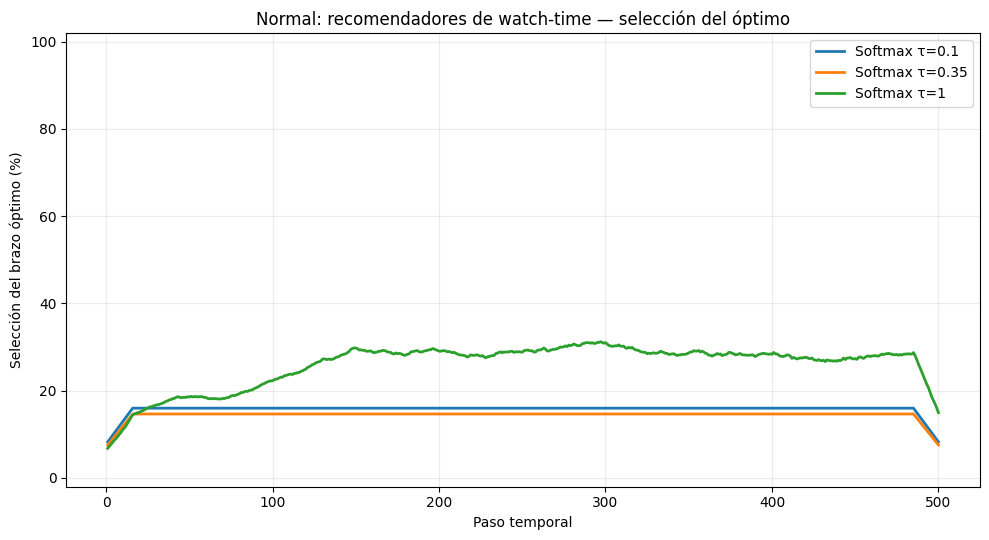

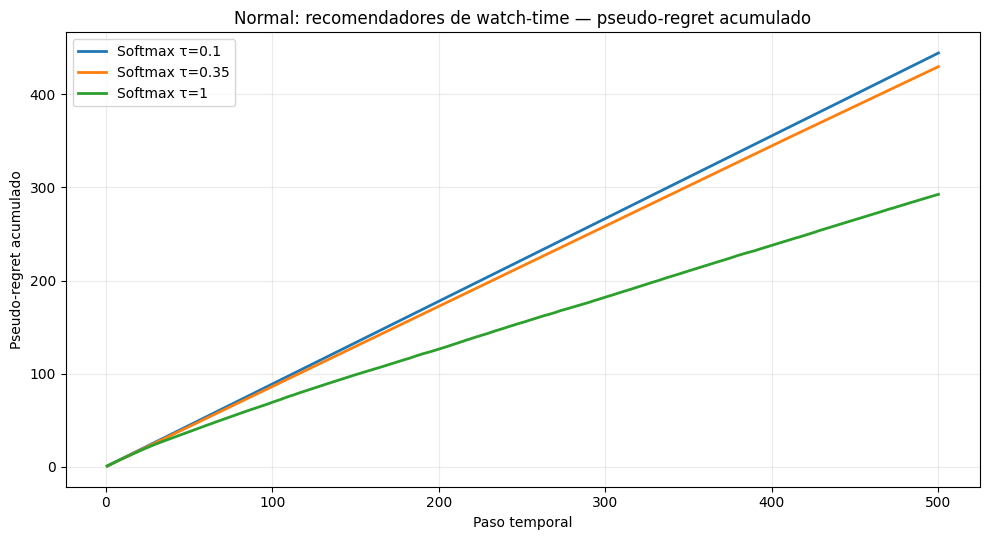

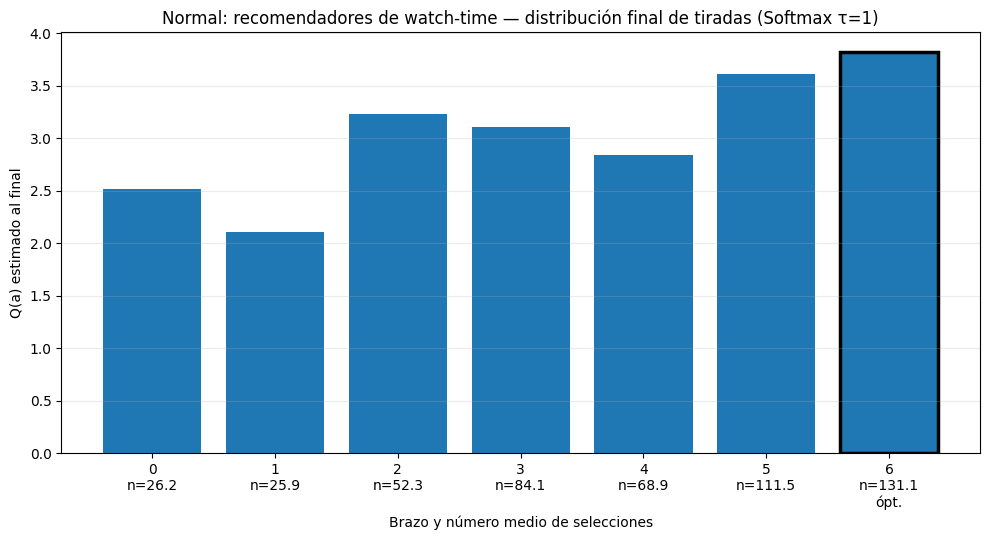

In [4]:
for key, spec in scenarios.items():
    display(Markdown(f"## {spec.title}\n\n{spec.rationale}\n\n```text\n{describe_bandit(spec.bandit)}\n```"))
    algorithms = algorithms_by_scenario[key]
    result = results[key]
    display(result[SUMMARY_NAME].round(4))
    plot_average_rewards(STEPS, result[REWARDS_NAME], algorithms, f"{spec.title} — recompensa media", smooth_window=SMOOTH_WINDOW)
    plot_optimal_selections(STEPS, result[OPTIMAL_NAME], algorithms, f"{spec.title} — selección del óptimo", smooth_window=SMOOTH_WINDOW)
    plot_regret(STEPS, result[REGRET_NAME], algorithms, f"{spec.title} — pseudo-regret acumulado")
    best_label = result[SUMMARY_NAME].iloc[0]["algoritmo"]
    plot_arm_statistics(result[ARM_STATS_NAME], best_label, f"{spec.title} — distribución final de tiradas ({best_label})")

## Síntesis intrafamilia

,escenario,algoritmo,recompensa_media_total,recompensa_media_último_20%,regret_final,% óptimo_final,% óptimo_último_20%,% tiradas_brazo_óptimo
0,Bernoulli: anuncios con CTR bajo,Softmax τ=0.1,0.0534,0.0540,4.8113,12.0000,14.0800,15.0160
1,Bernoulli: anuncios con CTR bajo,Softmax τ=0.35,0.0542,0.0571,4.9594,9.3333,15.0933,14.3067
2,Bernoulli: anuncios con CTR bajo,Softmax τ=1,0.0550,0.0557,4.9927,18.6667,14.0133,13.8987
3,Binomial: promociones por lotes,Softmax τ=1,12.8456,12.9995,1641.8923,21.3333,21.3333,20.3280
4,Binomial: promociones por lotes,Softmax τ=0.1,12.3039,12.2523,1915.2000,14.6667,14.6667,14.6667
5,Binomial: promociones por lotes,Softmax τ=0.35,12.2020,12.2371,1984.5333,18.6667,18.6667,18.6667
6,Normal: recomendadores de watch-time,Softmax τ=1,5.9668,5.9885,292.6233,34.6667,27.8800,26.2187
7,Normal: recomendadores de watch-time,Softmax τ=0.35,5.6781,5.7030,429.7140,14.6667,14.6667,14.6640
8,Normal: recomendadores de watch-time,Softmax τ=0.1,5.6611,5.6689,444.3440,16.0000,16.0000,16.0000


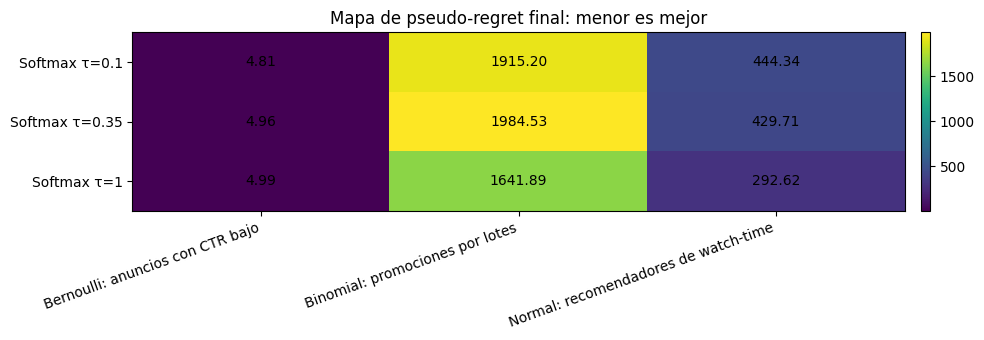

In [5]:
summary = BanditExperiment.collect_summaries(results, {k: s.title for k, s in scenarios.items()})
display(summary.round(4))
plot_summary_heatmap(summary, value="regret_final", title="Mapa de pseudo-regret final: menor es mejor")

## Lectura metodológica

Softmax suele mostrar diferencias fuertes entre escenarios porque `τ` actúa sobre los Q estimados. En recompensas con escala alta, una temperatura pequeña puede hacer que una diferencia inicial de recompensa concentre casi toda la probabilidad en un brazo antes de reunir evidencia suficiente. Por eso no basta con reportar recompensa: hay que inspeccionar regret y distribución final de tiradas.